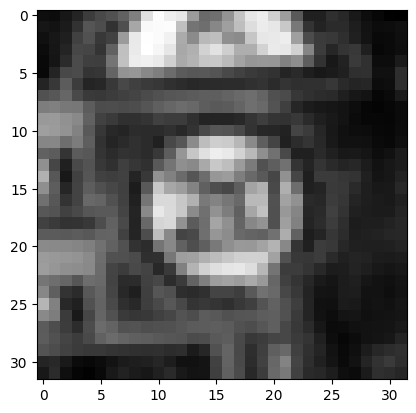

In [23]:
import numpy
import torchvision
import skimage
import matplotlib.pyplot as plt
import torchvision.transforms.v2

transform = torchvision.transforms.v2.Resize((32, 32), antialias=True)
train = torchvision.datasets.GTSRB("gtsrb", split="train", download=True, transform=transform)
img = numpy.array(train[0][0]) / 255
img = skimage.color.rgb2gray(img)
plt.imshow(img, cmap = 'gray')

In [50]:
import cvtda.utils

gray_image = img

min_, max_ = gray_image.min(), gray_image.max()
assert (min_ >= 0) and (max_ <= 1), f"Bad image format: should be [0, 1]; received [{min_}, {max_}]"

euler_numbers, area, perimeter = [], [], []
for threshold in range(256):
    bin = gray_image > threshold / 255.0
    euler_numbers.append(skimage.measure.euler_number(bin))
    area.append(bin.sum())
    perimeter.append(skimage.measure.perimeter(bin))
series = numpy.array([euler_numbers, area, perimeter])
series_diff = numpy.array([numpy.diff(euler_numbers), numpy.diff(area), numpy.diff(perimeter)])

f = numpy.concatenate(
    [
        cvtda.utils.sequence2features(series, reduced=True).flatten(),
        cvtda.utils.sequence2features(series_diff, reduced=True).flatten(),
    ]
)
f.shape, series.shape

((24,), (3, 256))

In [ ]:
sift = skimage.feature.SIFT()
sift.detect_and_extract(img)
sift_descriptors = sift.descriptors.transpose()

sift.keypoints

array([[ 3, 21],
       [ 3,  9],
       [ 4, 15],
       [ 5, 25],
       [ 6, 20],
       [ 6,  5],
       [12, 16],
       [17, 11],
       [18,  2],
       [21,  3],
       [24,  8],
       [25,  3],
       [28,  6],
       [ 7, 14],
       [10,  9],
       [23,  9],
       [25, 26],
       [19, 17],
       [ 3, 21],
       [ 3,  9],
       [21,  3],
       [10,  9]])

[[ 3 21]
 [ 3  9]
 [ 4 15]
 [ 5 25]
 [ 6 20]
 [ 6  5]
 [12 16]
 [17 11]
 [18  2]
 [21  3]
 [24  8]
 [25  3]
 [28  6]
 [ 7 14]
 [10  9]
 [23  9]
 [25 26]
 [19 17]
 [ 3 21]
 [ 3  9]
 [21  3]
 [10  9]]


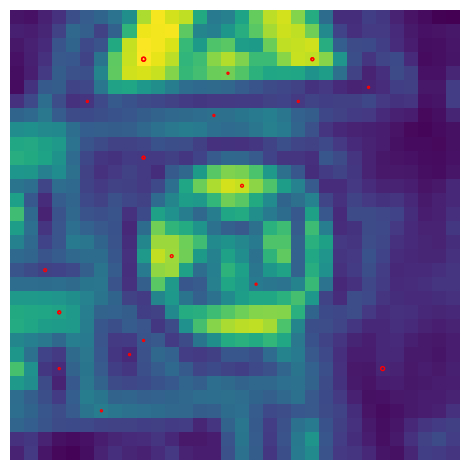

In [78]:
detector = skimage.feature.SIFT()
detector.detect(img)
plt.imshow(img)
plt.scatter(
    detector.keypoints[:, 1],
    detector.keypoints[:, 0],
    2**detector.scales,
    facecolors='none',
    edgecolors='r',
)
print(detector.keypoints)
plt.axis("off")
plt.gcf().tight_layout()

In [58]:
img.shape

(32, 32)

In [59]:
basic_features = skimage.feature.multiscale_basic_features(img)
basic_features.shape

(32, 32, 24)

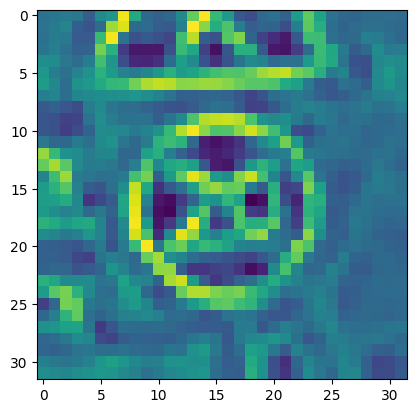

In [65]:
plt.imshow(basic_features[:, :, 2])

In [48]:
import cvtda.utils

basic_features = skimage.feature.multiscale_basic_features(img).reshape((-1, 24))
print(basic_features.shape)
cvtda.utils.sequence2features(
    numpy.ma.array(basic_features.transpose()), reduced=True
).flatten().shape

(1024, 24)


(72,)

In [40]:
import cvtda.topology

ge = cvtda.topology.GeometryExtractor()
ge.fit(numpy.array([ img ]))

GrayGeometryExtractor: 100%|██████████| 1/1 [00:00<00:00, 220.93it/s]


In [41]:
ge.transform(numpy.array([ img ]))

GrayGeometryExtractor: 100%|██████████| 1/1 [00:00<00:00,  1.11it/s]


array([[1.03777555e-03, 2.13337420e-03, 5.88592191e-03, ...,
        5.49859956e+02, 6.12423945e+01, 1.68284271e+01]])

In [42]:
ge.feature_names()

['daisy-0',
 'daisy-1',
 'daisy-2',
 'daisy-3',
 'daisy-4',
 'daisy-5',
 'daisy-6',
 'daisy-7',
 'daisy-8',
 'daisy-9',
 'daisy-10',
 'daisy-11',
 'daisy-12',
 'daisy-13',
 'daisy-14',
 'daisy-15',
 'daisy-16',
 'daisy-17',
 'daisy-18',
 'daisy-19',
 'daisy-20',
 'daisy-21',
 'daisy-22',
 'daisy-23',
 'daisy-24',
 'daisy-25',
 'daisy-26',
 'daisy-27',
 'daisy-28',
 'daisy-29',
 'daisy-30',
 'daisy-31',
 'daisy-32',
 'daisy-33',
 'daisy-34',
 'daisy-35',
 'daisy-36',
 'daisy-37',
 'daisy-38',
 'daisy-39',
 'daisy-40',
 'daisy-41',
 'daisy-42',
 'daisy-43',
 'daisy-44',
 'daisy-45',
 'daisy-46',
 'daisy-47',
 'daisy-48',
 'daisy-49',
 'daisy-50',
 'daisy-51',
 'daisy-52',
 'daisy-53',
 'daisy-54',
 'daisy-55',
 'daisy-56',
 'daisy-57',
 'daisy-58',
 'daisy-59',
 'daisy-60',
 'daisy-61',
 'daisy-62',
 'daisy-63',
 'daisy-64',
 'daisy-65',
 'daisy-66',
 'daisy-67',
 'daisy-68',
 'daisy-69',
 'daisy-70',
 'daisy-71',
 'daisy-72',
 'daisy-73',
 'daisy-74',
 'daisy-75',
 'daisy-76',
 'daisy-7

In [43]:
ge.explain("feature", img)

NotImplementedError: 

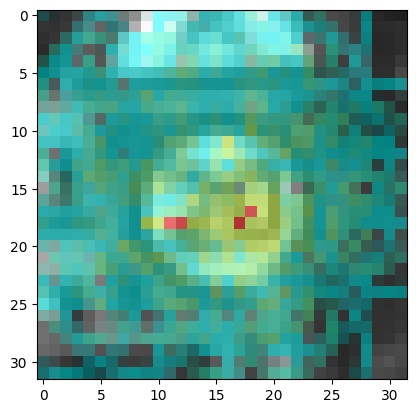

In [46]:
import skimage.feature

img2 = skimage.transform.resize(img, (360, 360), anti_aliasing = True)
img2 = img
image_shape = max(*img2.shape)
f, v = skimage.feature.daisy(
    img2,
    step=(6 * image_shape // 32), 
    radius=(12 * image_shape // 32),
    rings=5,
    histograms=5,
    orientations=8,
    visualize=True
)
import matplotlib.pyplot as plt
plt.imshow(img2, cmap = "gray")
plt.imshow(v, cmap="gray", alpha=0.5)

(15876,)
1.0


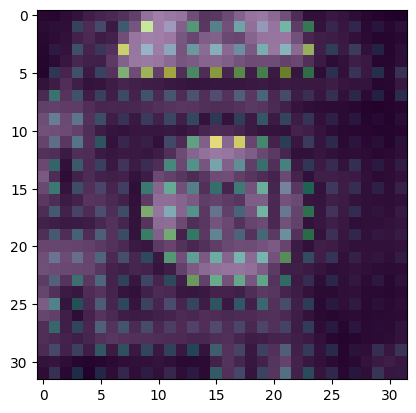

In [ ]:
import skimage.feature
fd, hog_image = skimage.feature.hog(
    # skimage.transform.resize(img, (360, 500), anti_aliasing = True),
    img,
    pixels_per_cell=(img.shape[0] // 16, img.shape[1] // 16),
    visualize = True
)
print(fd.shape)

hog_image /= hog_image.max()
# hog_image = skimage.exposure.rescale_intensity(hog_image, in_range = (0, 0.05))
print(hog_image.max())

plt.imshow(img, cmap = "gray")
plt.imshow(hog_image, cmap="gray", alpha=0.5)

In [51]:
fd.shape

(324,)

In [ ]:

img3 = skimage.transform.resize(img, (360, 500), anti_aliasing = True)